# ERA5 vs BARRA-RE2 all realizations on a common ERA5 grid

This notebook compares **ERA5** with **all BARRA-RE2 realizations** and the **BARRA-RE2 ensemble mean**.

BARRA-RE2 is higher resolution than ERA5, so direct cell-by-cell differences are not fair on native grids. Here, BARRA-RE2 is first **coarsened spatially** to approximately the ERA5 resolution and then **interpolated onto the ERA5 grid**. After that, all comparisons are made on the same ERA5 latitude/longitude grid.

Workflow:

1. Read yearly wind-drought binary masks for ERA5 and BARRA-RE2.
2. Compute annual wind-drought days for 1990-2025.
3. Compute climatological annual wind-drought days.
4. Keep all 22 BARRA-RE2 realizations separately.
5. Coarsen/regrid each BARRA realization to the ERA5 grid.
6. Compute BARRA ensemble mean on the ERA5 grid.
7. Calculate BARRA minus ERA5 differences.
8. Sort BARRA realizations by mean absolute difference from ERA5.
9. Plot ERA5 + BARRA mean + all BARRA realizations.
10. Plot BARRA mean and all BARRA realizations minus ERA5.


In [1]:
import os
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from tqdm.auto import tqdm


In [2]:
# =====================
# Settings
# =====================
BARRA_INPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly"
ERA5_INPUT_DIR = "/g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5"

OUTPUT_DIR = "/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid"
os.makedirs(OUTPUT_DIR, exist_ok=True)

START_YEAR = 1990
END_YEAR = 2025

lon_min, lon_max = 110, 160
lat_min, lat_max = -45, -10

threshold_percentile = 20
persistence_days = 3

BARRA_PATTERN = "wind_drought_P20_3day_*.nc"
ERA5_PATTERN = "wind_drought_P20_3day_*.nc"

# Same style as the ERA5 frequency template
levels = np.arange(3, 42, 3)

OUT_BARRA_NC = os.path.join(
    OUTPUT_DIR,
    "BARRA_RE2_ALL_REALIZATIONS_AND_MEAN_COARSENED_TO_ERA5_GRID_1990_2025.nc"
)

OUT_ERA5_NC = os.path.join(
    OUTPUT_DIR,
    "ERA5_P20_3day_climatological_wind_drought_days_1990_2025_COMMON_GRID_REFERENCE.nc"
)

OUT_SUMMARY_CSV = os.path.join(
    OUTPUT_DIR,
    "BARRA_RE2_realization_similarity_to_ERA5_common_grid_summary.csv"
)

OUT_MAIN_FIG = os.path.join(
    OUTPUT_DIR,
    "ERA5_plus_BARRA_RE2_mean_plus_all_realizations_COMMON_ERA5_GRID_sorted_by_difference_1990_2025.png"
)

OUT_DIFF_FIG = os.path.join(
    OUTPUT_DIR,
    "BARRA_RE2_mean_and_all_realizations_minus_ERA5_COMMON_ERA5_GRID_sorted_by_difference_1990_2025.png"
)

print("Output directory:", OUTPUT_DIR)


Output directory: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid


## Helper functions

In [3]:
def year_from_filename(fp):
    return int(os.path.basename(fp).split("_")[-1].split(".")[0])


def get_year_files(input_dir, pattern, start_year, end_year):
    files = sorted(glob(os.path.join(input_dir, pattern)))
    out = []
    for fp in files:
        yr = year_from_filename(fp)
        if start_year <= yr <= end_year:
            out.append(fp)
    if len(out) == 0:
        raise FileNotFoundError(f"No files found in {input_dir} for {start_year}-{end_year}")
    return out


def get_var_name(ds):
    if "wind_drought" in ds.data_vars:
        return "wind_drought"
    return list(ds.data_vars)[0]


def get_lon_lat_names(obj):
    names = list(obj.coords) + list(obj.dims)

    if "lon" in names:
        lon_name = "lon"
    elif "longitude" in names:
        lon_name = "longitude"
    else:
        raise KeyError("Could not find lon or longitude coordinate")

    if "lat" in names:
        lat_name = "lat"
    elif "latitude" in names:
        lat_name = "latitude"
    else:
        raise KeyError("Could not find lat or latitude coordinate")

    return lon_name, lat_name


def crop_australia(da):
    lon_name, lat_name = get_lon_lat_names(da)
    lon = da[lon_name]
    lat = da[lat_name]

    return da.where(
        (lon >= lon_min) & (lon <= lon_max) &
        (lat >= lat_min) & (lat <= lat_max),
        drop=True
    )


def standardise_spatial(da):
    # Rename lon/lat to longitude/latitude, sort ascending, put spatial dims last.
    rename = {}

    if "lon" in da.dims:
        rename["lon"] = "longitude"
    if "lat" in da.dims:
        rename["lat"] = "latitude"
    if "lon" in da.coords:
        rename["lon"] = "longitude"
    if "lat" in da.coords:
        rename["lat"] = "latitude"

    if rename:
        da = da.rename(rename)

    if "latitude" not in da.dims or "longitude" not in da.dims:
        raise ValueError(f"Expected latitude and longitude dims. Found dims: {da.dims}")

    if da["latitude"].ndim == 1:
        da = da.sortby("latitude")
    if da["longitude"].ndim == 1:
        da = da.sortby("longitude")

    other_dims = [d for d in da.dims if d not in ["latitude", "longitude"]]
    da = da.transpose(*other_dims, "latitude", "longitude")

    return da


def standardise_for_plot(da):
    # Return a 2D DataArray as latitude, longitude for contourf.
    da = standardise_spatial(da)

    for d in list(da.dims):
        if d not in ["latitude", "longitude"]:
            if da.sizes[d] == 1:
                da = da.isel({d: 0}, drop=True)
            else:
                raise ValueError(f"Unexpected non-spatial dimension for plotting: {d}")

    da = da.transpose("latitude", "longitude")
    return da


def get_grid_resolution(da):
    da = standardise_spatial(da)
    lat_res = float(np.nanmedian(np.abs(np.diff(da["latitude"].values))))
    lon_res = float(np.nanmedian(np.abs(np.diff(da["longitude"].values))))
    return lat_res, lon_res


def coarsen_then_interp_to_era5_grid(barra_da, era5_template, verbose=True):
    barra_da = standardise_spatial(barra_da)
    era5_template = standardise_for_plot(era5_template)

    barra_lat_res, barra_lon_res = get_grid_resolution(barra_da)
    era5_lat_res, era5_lon_res = get_grid_resolution(era5_template)

    lat_factor = max(1, int(round(era5_lat_res / barra_lat_res)))
    lon_factor = max(1, int(round(era5_lon_res / barra_lon_res)))

    if verbose:
        print(
            f"BARRA resolution lat/lon = {barra_lat_res:.4f}/{barra_lon_res:.4f}; "
            f"ERA5 resolution lat/lon = {era5_lat_res:.4f}/{era5_lon_res:.4f}; "
            f"coarsen factors lat/lon = {lat_factor}/{lon_factor}"
        )

    if lat_factor > 1 or lon_factor > 1:
        coarse = barra_da.coarsen(
            latitude=lat_factor,
            longitude=lon_factor,
            boundary="trim"
        ).mean(skipna=True)
    else:
        coarse = barra_da

    target_lats = era5_template["latitude"]
    target_lons = era5_template["longitude"]

    linear = coarse.interp(
        latitude=target_lats,
        longitude=target_lons,
        method="linear"
    )

    nearest = coarse.interp(
        latitude=target_lats,
        longitude=target_lons,
        method="nearest"
    )

    out = linear.fillna(nearest).astype("float32")
    out.attrs.update(barra_da.attrs)
    out.attrs["regridding_method"] = (
        "BARRA spatially coarsened using xarray.coarsen(mean) to approximate ERA5 resolution, "
        "then interpolated to the ERA5 latitude/longitude grid using linear interpolation, "
        "with nearest-neighbour edge fill."
    )
    out.attrs["lat_coarsen_factor"] = lat_factor
    out.attrs["lon_coarsen_factor"] = lon_factor

    return out


def compute_similarity_metrics(candidate, reference):
    candidate, reference = xr.align(candidate, reference, join="inner")
    diff = candidate - reference
    mad = float(np.abs(diff).mean(skipna=True).values)
    bias = float(diff.mean(skipna=True).values)
    rmse = float(np.sqrt((diff ** 2).mean(skipna=True).values))
    return diff.astype("float32"), mad, bias, rmse


## Find and inspect input files

In [4]:
barra_files = get_year_files(BARRA_INPUT_DIR, BARRA_PATTERN, START_YEAR, END_YEAR)
era5_files = get_year_files(ERA5_INPUT_DIR, ERA5_PATTERN, START_YEAR, END_YEAR)

print("BARRA files:", len(barra_files))
print("BARRA first:", barra_files[0])
print("BARRA last :", barra_files[-1])

print("ERA5 files:", len(era5_files))
print("ERA5 first:", era5_files[0])
print("ERA5 last :", era5_files[-1])


BARRA files: 36
BARRA first: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_1990.nc
BARRA last : /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/wind_drought_P20_3day_2025.nc
ERA5 files: 36
ERA5 first: /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_1990.nc
ERA5 last : /g/data/nf33/WindDroughts_Group3/ls3248/wind_drought_ERA5/wind_drought_P20_3day_2025.nc


In [6]:
with xr.open_dataset(barra_files[0], engine="netcdf4", decode_times=True) as ds0:
    barra_var = get_var_name(ds0)
    print("BARRA dataset:")
    print(ds0)
    print("BARRA variable:", barra_var)
    print("BARRA dims:", ds0[barra_var].dims)

with xr.open_dataset(era5_files[0], engine="netcdf4", decode_times=True) as ds0:
    era5_var = get_var_name(ds0)
    print("ERA5 dataset:")
    print(ds0)
    print("ERA5 variable:", era5_var)
    print("ERA5 dims:", ds0[era5_var].dims)


BARRA dataset:
<xarray.Dataset> Size: 1GB
Dimensions:       (time: 365, realization: 22, lon: 227, lat: 159)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01T12:00:00 ... 1990-12-3...
  * realization   (realization) <U5 440B '000_0' '000_1' ... 'ctl_0' 'ctl_1'
  * lon           (lon) float64 2kB 110.2 110.4 110.7 ... 159.5 159.7 159.9
  * lat           (lat) float64 1kB -44.83 -44.61 -44.39 ... -10.29 -10.07
Data variables:
    wind_drought  (time, realization, lon, lat) float32 1GB ...
Attributes:
    title:    BARRA-RE2 wind drought mask for 1990
    history:  Created from monthly wind100 files using fixed 1991-2020 P20 th...
    region:   Australia
    lon_min:  110
    lon_max:  160
    lat_min:  -45
    lat_max:  -10
BARRA variable: wind_drought
BARRA dims: ('time', 'realization', 'lon', 'lat')
ERA5 dataset:
<xarray.Dataset> Size: 10MB
Dimensions:       (time: 365, latitude: 141, longitude: 201)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1990-01-01

## Compute BARRA-RE2 climatology for each realization

In [7]:
barra_annual_list = []
barra_years = []
realization_values = None

for fp in tqdm(barra_files, desc="BARRA yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[barra_var]

    wd = crop_australia(wd)

    days = wd.sum(dim="time", skipna=True).astype("float32")
    days = standardise_spatial(days)
    days.name = "annual_wind_drought_days"
    days.attrs["units"] = "days/year"
    days.attrs["realization_handling"] = "BARRA-RE2 realizations kept separate"

    if realization_values is None and "realization" in days.coords:
        realization_values = days["realization"].values

    barra_annual_list.append(days.load())
    barra_years.append(year)

    ds.close()

barra_annual = xr.concat(barra_annual_list, dim="year")
barra_annual = barra_annual.assign_coords(year=barra_years)
barra_annual.name = "annual_wind_drought_days_by_realization"

barra_clim_by_realization_native = barra_annual.mean(dim="year", skipna=True).astype("float32")
barra_clim_by_realization_native.name = "climatological_wind_drought_days_by_realization_native_grid"
barra_clim_by_realization_native.attrs["long_name"] = "Climatological annual wind drought days for each BARRA-RE2 realization on native grid"
barra_clim_by_realization_native.attrs["units"] = "days/year"
barra_clim_by_realization_native.attrs["period"] = f"{START_YEAR}-{END_YEAR}"

print(barra_annual)
print(barra_clim_by_realization_native)


BARRA yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

<xarray.DataArray 'annual_wind_drought_days_by_realization' (year: 36,
                                                             realization: 22,
                                                             latitude: 159,
                                                             longitude: 227)> Size: 114MB
array([[[[25., 25., 28., ..., 19., 23., 17.],
         [25., 29., 29., ..., 18., 15., 15.],
         [29., 29., 29., ..., 15., 13., 12.],
         ...,
         [63., 62., 63., ..., 27., 29., 29.],
         [64., 63., 64., ..., 27., 26., 19.],
         [61., 68., 66., ..., 23., 23., 24.]],

        [[26., 26., 27., ..., 22., 22., 15.],
         [26., 30., 32., ..., 21., 15., 12.],
         [30., 32., 32., ..., 18., 12., 12.],
         ...,
         [65., 65., 70., ..., 30., 36., 32.],
         [65., 65., 73., ..., 32., 35., 27.],
         [71., 71., 71., ..., 29., 31., 30.]],

        [[23., 25., 25., ..., 14., 14., 14.],
         [23., 20., 20., ..., 18., 19., 16.],
         

## Compute ERA5 climatology

In [8]:
era5_annual_list = []
era5_years = []

for fp in tqdm(era5_files, desc="ERA5 yearly files"):
    year = year_from_filename(fp)

    ds = xr.open_dataset(fp, engine="netcdf4", decode_times=True)
    wd = ds[era5_var]

    wd = crop_australia(wd)

    days = wd.sum(dim="time", skipna=True).astype("float32")
    days = standardise_for_plot(days)
    days.name = "annual_wind_drought_days"
    days.attrs["units"] = "days/year"

    era5_annual_list.append(days.load())
    era5_years.append(year)

    ds.close()

era5_annual = xr.concat(era5_annual_list, dim="year")
era5_annual = era5_annual.assign_coords(year=era5_years)
era5_annual.name = "annual_wind_drought_days"

era5_clim = era5_annual.mean(dim="year", skipna=True).astype("float32")
era5_clim.name = "climatological_wind_drought_days"
era5_clim.attrs["long_name"] = "ERA5 climatological annual wind drought days"
era5_clim.attrs["units"] = "days/year"
era5_clim.attrs["period"] = f"{START_YEAR}-{END_YEAR}"

era5_plot = standardise_for_plot(era5_clim)

print(era5_annual)
print(era5_plot)


ERA5 yearly files:   0%|          | 0/36 [00:00<?, ?it/s]

<xarray.DataArray 'annual_wind_drought_days' (year: 36, latitude: 141,
                                              longitude: 201)> Size: 4MB
array([[[13., 13., 13., ..., 16., 16., 19.],
        [16., 16., 19., ..., 19., 19., 19.],
        [19., 19., 19., ..., 22., 22., 22.],
        ...,
        [42., 44., 43., ..., 37., 38., 48.],
        [47., 44., 39., ..., 37., 38., 47.],
        [48., 50., 50., ..., 30., 37., 47.]],

       [[44., 41., 41., ..., 19., 19., 19.],
        [41., 41., 41., ..., 20., 22., 13.],
        [45., 44., 41., ..., 13., 12., 16.],
        ...,
        [67., 68., 68., ..., 42., 44., 43.],
        [69., 64., 72., ..., 40., 44., 46.],
        [73., 72., 71., ..., 27., 36., 33.]],

       [[29., 25., 32., ..., 18., 21., 20.],
        [27., 28., 28., ..., 21., 16., 13.],
        [25., 25., 28., ..., 13., 16., 16.],
        ...,
...
        [49., 52., 51., ..., 54., 47., 57.],
        [48., 48., 44., ..., 43., 49., 55.],
        [46., 46., 39., ..., 45., 42., 63.]]

## Coarsen/regrid BARRA to ERA5 grid

In [9]:
barra_regridded_list = []
realization_labels = []

n_real = barra_clim_by_realization_native.sizes["realization"]

for i in tqdm(range(n_real), desc="Coarsen and regrid BARRA realizations"):
    da_i = barra_clim_by_realization_native.isel(realization=i)
    da_i = da_i.drop_vars("realization", errors="ignore")

    da_i_era5_grid = coarsen_then_interp_to_era5_grid(
        da_i,
        era5_plot,
        verbose=(i == 0)
    )
    da_i_era5_grid = da_i_era5_grid.expand_dims(
        realization=[barra_clim_by_realization_native["realization"].values[i]]
    )

    barra_regridded_list.append(da_i_era5_grid)

    if "realization" in barra_clim_by_realization_native.coords:
        realization_labels.append(str(barra_clim_by_realization_native["realization"].values[i]))
    else:
        realization_labels.append(str(i))

barra_clim_by_realization_era5_grid = xr.concat(barra_regridded_list, dim="realization")
barra_clim_by_realization_era5_grid.name = "climatological_wind_drought_days_by_realization_on_ERA5_grid"
barra_clim_by_realization_era5_grid.attrs["units"] = "days/year"
barra_clim_by_realization_era5_grid.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_clim_by_realization_era5_grid.attrs["grid"] = "ERA5 latitude/longitude grid"

barra_clim_mean_era5_grid = barra_clim_by_realization_era5_grid.mean(dim="realization", skipna=True).astype("float32")
barra_clim_mean_era5_grid.name = "climatological_wind_drought_days_ensemble_mean_on_ERA5_grid"
barra_clim_mean_era5_grid.attrs["units"] = "days/year"
barra_clim_mean_era5_grid.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_clim_mean_era5_grid.attrs["grid"] = "ERA5 latitude/longitude grid"

print(barra_clim_by_realization_era5_grid)
print(barra_clim_mean_era5_grid)
print("Realization labels:", realization_labels)


Coarsen and regrid BARRA realizations:   0%|          | 0/22 [00:00<?, ?it/s]

BARRA resolution lat/lon = 0.2200/0.2200; ERA5 resolution lat/lon = 0.2500/0.2500; coarsen factors lat/lon = 1/1
<xarray.DataArray 'climatological_wind_drought_days_by_realization_on_ERA5_grid' (
                                                                                  realization: 22,
                                                                                  latitude: 141,
                                                                                  longitude: 201)> Size: 2MB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan, 23.873508, 24.17275 , ..., 18.77468 , 19.339762,
               nan],
        [      nan, 24.935606, 25.043562, ..., 18.984848, 19.194445,
               nan],
        ...,
        [      nan, 55.84757 , 56.155476, ..., 46.63929 , 45.80705 ,
               nan],
        [      nan, 56.28191 , 56.398876, ..., 44.45627 , 44.737602,
               nan],
        [      nan,       nan,      

## Calculate differences from ERA5 and sort BARRA realizations

In [10]:
barra_mean_diff, barra_mean_mad, barra_mean_bias, barra_mean_rmse = compute_similarity_metrics(
    barra_clim_mean_era5_grid,
    era5_plot
)

barra_plot_fields = []
barra_diff_fields = []
mad_values = []
bias_values = []
rmse_values = []

for i in range(n_real):
    da_i = barra_clim_by_realization_era5_grid.isel(realization=i, drop=True)
    da_i = standardise_for_plot(da_i)

    diff_i, mad_i, bias_i, rmse_i = compute_similarity_metrics(da_i, era5_plot)

    barra_plot_fields.append(da_i)
    barra_diff_fields.append(diff_i)
    mad_values.append(mad_i)
    bias_values.append(bias_i)
    rmse_values.append(rmse_i)

sort_idx = np.argsort(np.array(mad_values))

barra_plot_fields_sorted = [barra_plot_fields[i] for i in sort_idx]
barra_diff_fields_sorted = [barra_diff_fields[i] for i in sort_idx]
realization_labels_sorted = [realization_labels[i] for i in sort_idx]
mad_values_sorted = [mad_values[i] for i in sort_idx]
bias_values_sorted = [bias_values[i] for i in sort_idx]
rmse_values_sorted = [rmse_values[i] for i in sort_idx]

summary_df = pd.DataFrame({
    "sort_rank_by_MAD": np.arange(1, n_real + 1),
    "realization": realization_labels_sorted,
    "MAD_vs_ERA5_days": mad_values_sorted,
    "MeanBias_vs_ERA5_days": bias_values_sorted,
    "RMSE_vs_ERA5_days": rmse_values_sorted,
})

summary_df.to_csv(OUT_SUMMARY_CSV, index=False)

print("BARRA ensemble mean MAD:", barra_mean_mad)
print("BARRA ensemble mean bias:", barra_mean_bias)
print("BARRA ensemble mean RMSE:", barra_mean_rmse)
print("Saved summary CSV:", OUT_SUMMARY_CSV)
summary_df.head(10)


BARRA ensemble mean MAD: 1.4280307292938232
BARRA ensemble mean bias: -0.8185362219810486
BARRA ensemble mean RMSE: 1.936042070388794
Saved summary CSV: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/BARRA_RE2_realization_similarity_to_ERA5_common_grid_summary.csv


,sort_rank_by_MAD,realization,MAD_vs_ERA5_days,MeanBias_vs_ERA5_days,RMSE_vs_ERA5_days
0,1,000_1,1.169617,-0.183120,1.516556
1,2,ctl_1,1.182203,-0.106774,1.540911
2,3,ctl_0,1.196610,-0.176171,1.570214
3,4,000_0,1.276406,-0.434162,1.701201
4,5,001_1,1.420481,-0.696009,1.902498
5,6,002_1,1.433211,-0.689037,1.923723
6,7,007_1,1.433530,-0.699741,1.911267
7,8,005_1,1.441366,-0.703004,1.918938
8,9,004_1,1.452725,-0.757973,1.927322
9,10,009_1,1.453886,-0.724925,1.925413


## Save common-grid outputs

In [11]:
barra_diff_by_realization = xr.concat(
    [d.expand_dims(realization=[barra_clim_by_realization_era5_grid["realization"].values[i]]) for i, d in enumerate(barra_diff_fields)],
    dim="realization"
).transpose("realization", "latitude", "longitude")
barra_diff_by_realization.name = "difference_from_ERA5_by_realization_on_ERA5_grid"
barra_diff_by_realization.attrs["units"] = "days/year"
barra_diff_by_realization.attrs["description"] = "BARRA-RE2 realization minus ERA5 climatological annual wind drought days on ERA5 grid"

barra_mean_diff.name = "difference_from_ERA5_ensemble_mean_on_ERA5_grid"
barra_mean_diff.attrs["units"] = "days/year"
barra_mean_diff.attrs["description"] = "BARRA-RE2 ensemble mean minus ERA5 climatological annual wind drought days on ERA5 grid"

barra_out_ds = xr.Dataset(
    {
        "annual_wind_drought_days_by_realization_native_grid": barra_annual,
        "climatological_wind_drought_days_by_realization_native_grid": barra_clim_by_realization_native,
        "climatological_wind_drought_days_by_realization_on_ERA5_grid": barra_clim_by_realization_era5_grid,
        "climatological_wind_drought_days_ensemble_mean_on_ERA5_grid": barra_clim_mean_era5_grid,
        "difference_from_ERA5_by_realization_on_ERA5_grid": barra_diff_by_realization,
        "difference_from_ERA5_ensemble_mean_on_ERA5_grid": barra_mean_diff,
        "MAD_from_ERA5_by_realization_days": xr.DataArray(
            np.array(mad_values, dtype="float32"),
            dims=["realization"],
            coords={"realization": barra_clim_by_realization_era5_grid["realization"].values},
        ),
        "MeanBias_from_ERA5_by_realization_days": xr.DataArray(
            np.array(bias_values, dtype="float32"),
            dims=["realization"],
            coords={"realization": barra_clim_by_realization_era5_grid["realization"].values},
        ),
        "RMSE_from_ERA5_by_realization_days": xr.DataArray(
            np.array(rmse_values, dtype="float32"),
            dims=["realization"],
            coords={"realization": barra_clim_by_realization_era5_grid["realization"].values},
        ),
    }
)

barra_out_ds.attrs["title"] = "BARRA-RE2 all realizations and ensemble mean wind drought frequency coarsened to ERA5 grid"
barra_out_ds.attrs["description"] = (
    "BARRA-RE2 annual and climatological wind drought days for each realization, with BARRA spatially coarsened "
    "and interpolated to ERA5 grid before comparison. Includes BARRA minus ERA5 differences and similarity metrics."
)
barra_out_ds.attrs["period"] = f"{START_YEAR}-{END_YEAR}"
barra_out_ds.attrs["threshold_percentile"] = threshold_percentile
barra_out_ds.attrs["persistence_days"] = persistence_days
barra_out_ds.attrs["difference_reference"] = "ERA5 climatological annual wind drought days"
barra_out_ds.attrs["sorting_metric"] = "Mean absolute difference (MAD) from ERA5 after coarsening/regridding to ERA5 grid"

barra_out_ds.to_netcdf(OUT_BARRA_NC)
print("Saved BARRA output:", OUT_BARRA_NC)


era5_out_ds = xr.Dataset(
    {
        "annual_wind_drought_days": era5_annual,
        "climatological_wind_drought_days": era5_plot,
    }
)

era5_out_ds.attrs["title"] = "ERA5 wind drought frequency, common-grid reference"
era5_out_ds.attrs["description"] = f"ERA5 annual and climatological wind drought days for {START_YEAR}-{END_YEAR}. Used as comparison grid."
era5_out_ds.attrs["threshold_percentile"] = threshold_percentile
era5_out_ds.attrs["persistence_days"] = persistence_days

era5_out_ds.to_netcdf(OUT_ERA5_NC)
print("Saved ERA5 output:", OUT_ERA5_NC)


Saved BARRA output: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/BARRA_RE2_ALL_REALIZATIONS_AND_MEAN_COARSENED_TO_ERA5_GRID_1990_2025.nc
Saved ERA5 output: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/ERA5_P20_3day_climatological_wind_drought_days_1990_2025_COMMON_GRID_REFERENCE.nc


## Figure 1: ERA5 plus BARRA mean plus all BARRA realizations on ERA5 grid

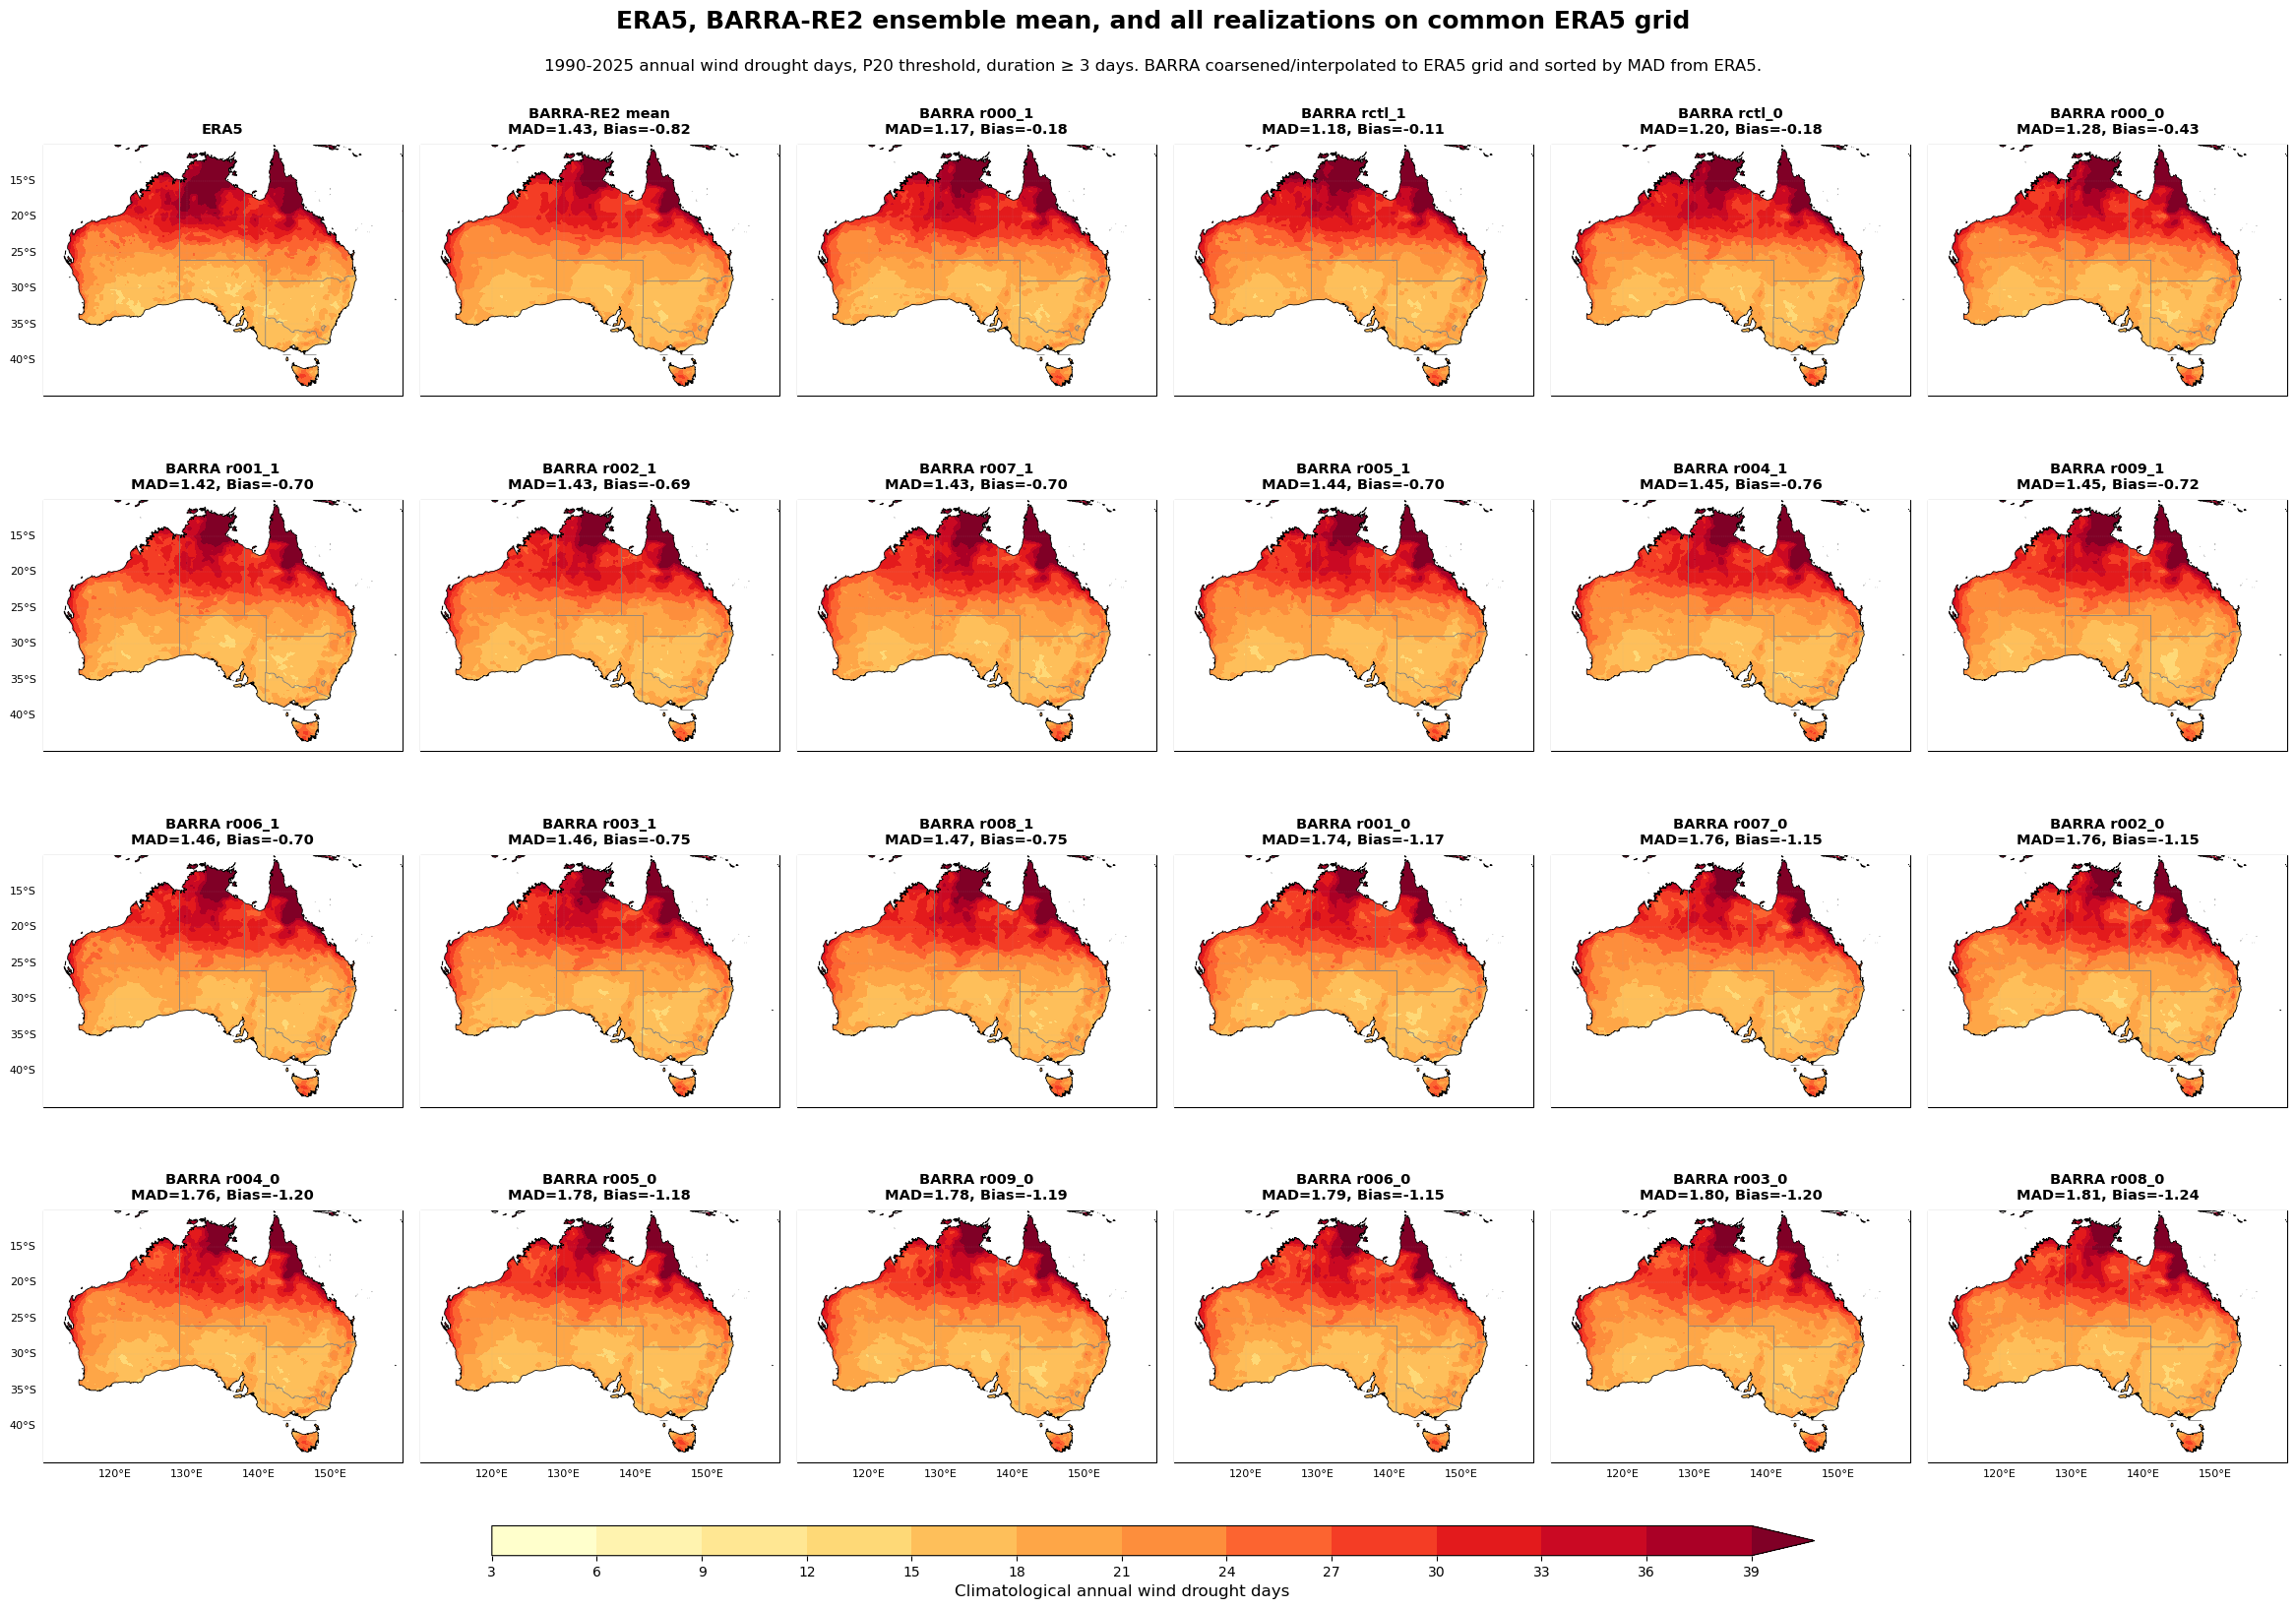

Saved main figure: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/ERA5_plus_BARRA_RE2_mean_plus_all_realizations_COMMON_ERA5_GRID_sorted_by_difference_1990_2025.png


In [12]:
cmap = plt.cm.YlOrRd.copy()
cmap.set_under("white")
cmap.set_bad("white")

norm = mcolors.BoundaryNorm(levels, cmap.N, extend="max")

panel_data = [("ERA5", era5_plot)]
panel_data.append((f"BARRA-RE2 mean\nMAD={barra_mean_mad:.2f}, Bias={barra_mean_bias:+.2f}", barra_clim_mean_era5_grid))

for label, da, mad_i, bias_i in zip(realization_labels_sorted, barra_plot_fields_sorted, mad_values_sorted, bias_values_sorted):
    panel_data.append((f"BARRA r{label}\nMAD={mad_i:.2f}, Bias={bias_i:+.2f}", da))

n_panels = len(panel_data)
ncols = 6
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 4.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False
)

axes = np.asarray(axes).ravel()

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

cf = None

for idx, (title, da) in enumerate(panel_data):
    ax = axes[idx]
    da = standardise_for_plot(da)

    cf = ax.contourf(
        da["longitude"],
        da["latitude"],
        da,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="max",
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=100)
    ax.coastlines(resolution="10m", linewidth=0.55, color="black", zorder=101)
    ax.add_feature(states, edgecolor="grey", linewidth=0.55, zorder=102)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.25, linestyle="--", alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False

    row = idx // ncols
    col = idx % ncols
    gl.left_labels = (col == 0)
    gl.bottom_labels = (row == nrows - 1)

    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=8)

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

cbar_ax = fig.add_axes([0.22, 0.05, 0.56, 0.018])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Climatological annual wind drought days", fontsize=12)
cbar.set_ticks(levels)
cbar.ax.tick_params(labelsize=10)

fig.suptitle(
    "ERA5, BARRA-RE2 ensemble mean, and all realizations on common ERA5 grid",
    fontsize=18,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.955,
    "1990-2025 annual wind drought days, P20 threshold, duration ≥ 3 days. BARRA coarsened/interpolated to ERA5 grid and sorted by MAD from ERA5.",
    ha="center",
    va="top",
    fontsize=12
)

plt.subplots_adjust(left=0.03, right=0.98, top=0.92, bottom=0.09, wspace=0.05, hspace=0.16)
plt.savefig(OUT_MAIN_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved main figure:", OUT_MAIN_FIG)


## Figure 2: BARRA minus ERA5 difference maps on ERA5 grid

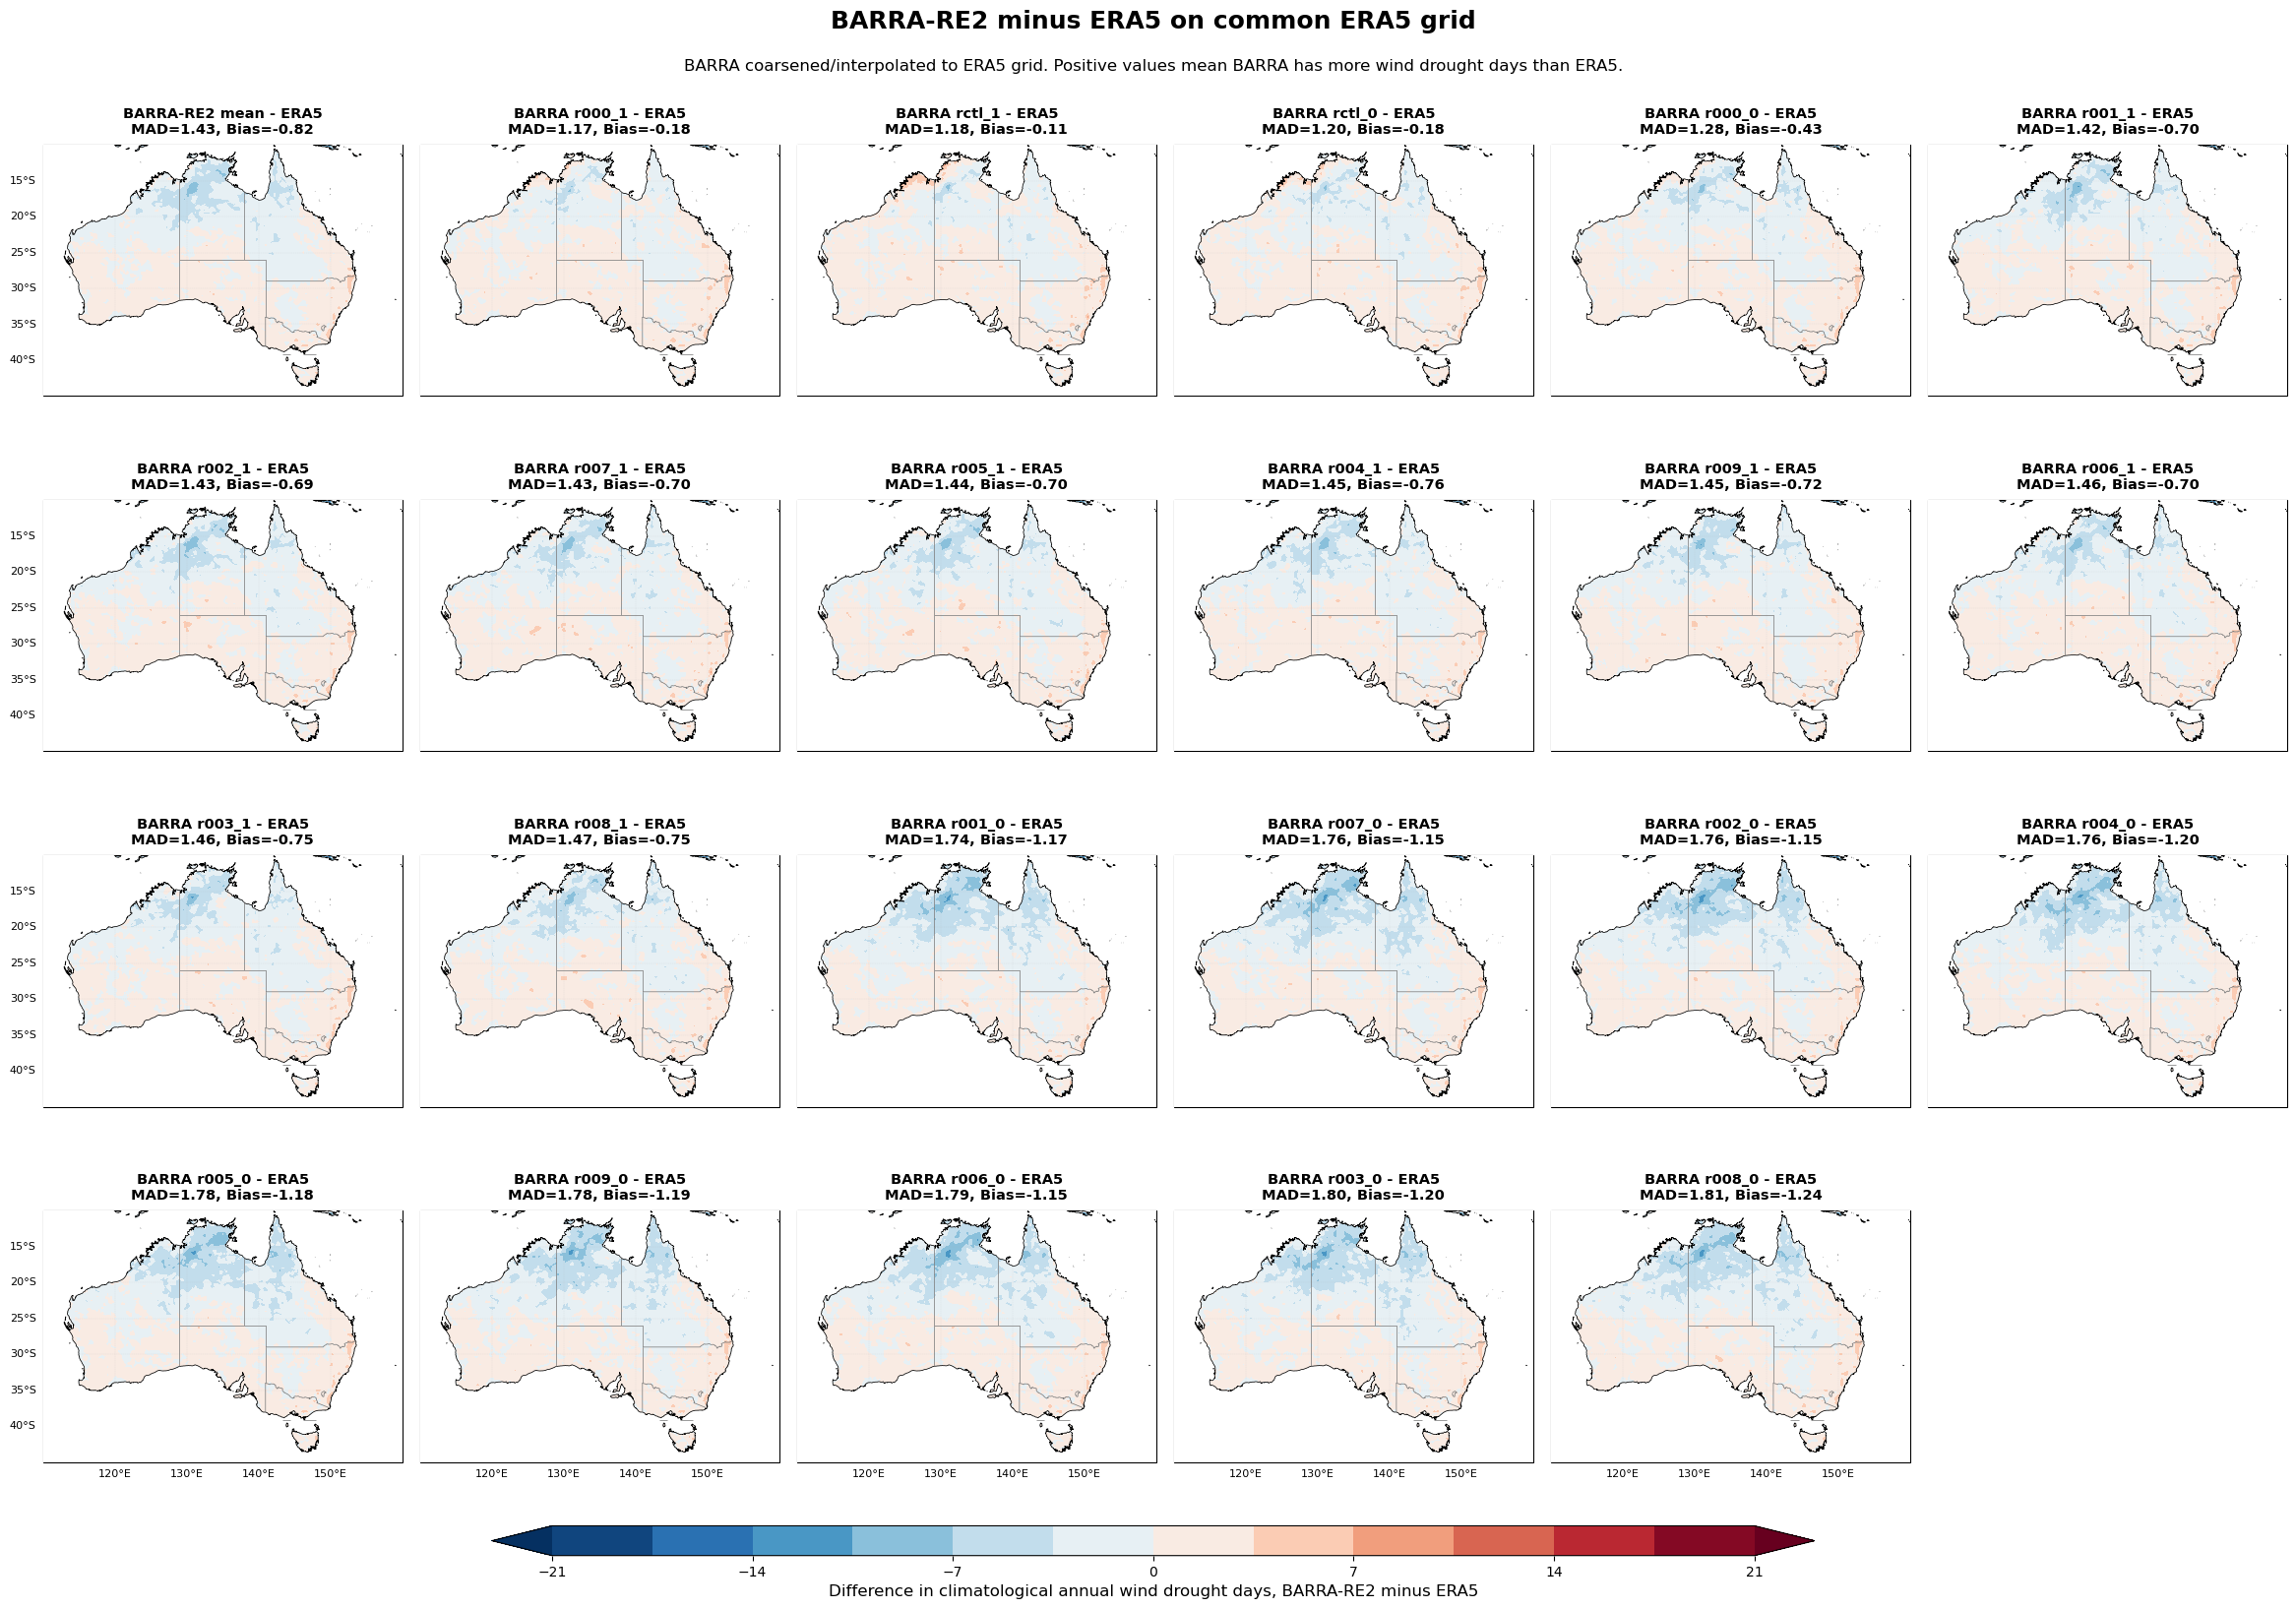

Saved difference figure: /scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/BARRA_RE2_mean_and_all_realizations_minus_ERA5_COMMON_ERA5_GRID_sorted_by_difference_1990_2025.png


In [13]:
all_diff_arrays = [barra_mean_diff.values] + [d.values for d in barra_diff_fields_sorted]
max_abs = max(float(np.nanmax(np.abs(a))) for a in all_diff_arrays)
vmax = max(6.0, float(np.ceil(max_abs / 3.0) * 3.0))
diff_levels = np.linspace(-vmax, vmax, 13)
diff_cmap = plt.cm.RdBu_r

diff_panel_data = [(f"BARRA-RE2 mean - ERA5\nMAD={barra_mean_mad:.2f}, Bias={barra_mean_bias:+.2f}", barra_mean_diff)]

for label, diff_i, mad_i, bias_i in zip(realization_labels_sorted, barra_diff_fields_sorted, mad_values_sorted, bias_values_sorted):
    diff_panel_data.append((f"BARRA r{label} - ERA5\nMAD={mad_i:.2f}, Bias={bias_i:+.2f}", diff_i))

n_panels = len(diff_panel_data)
ncols = 6
nrows = int(np.ceil(n_panels / ncols))

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(24, 4.2 * nrows),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False
)

axes = np.asarray(axes).ravel()

states = cfeature.NaturalEarthFeature(
    category="cultural",
    name="admin_1_states_provinces_lines",
    scale="10m",
    facecolor="none"
)

cf = None

for idx, (title, da) in enumerate(diff_panel_data):
    ax = axes[idx]
    da = standardise_for_plot(da)

    cf = ax.contourf(
        da["longitude"],
        da["latitude"],
        da,
        levels=diff_levels,
        cmap=diff_cmap,
        extend="both",
        transform=ccrs.PlateCarree()
    )

    ax.add_feature(cfeature.OCEAN, facecolor="white", edgecolor="none", zorder=100)
    ax.coastlines(resolution="10m", linewidth=0.55, color="black", zorder=101)
    ax.add_feature(states, edgecolor="grey", linewidth=0.55, zorder=102)
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.25, linestyle="--", alpha=0.35)
    gl.top_labels = False
    gl.right_labels = False

    row = idx // ncols
    col = idx % ncols
    gl.left_labels = (col == 0)
    gl.bottom_labels = (row == nrows - 1)

    gl.xlabel_style = {"size": 8}
    gl.ylabel_style = {"size": 8}

    ax.set_title(title, fontsize=10.5, fontweight="bold", pad=8)

for j in range(n_panels, len(axes)):
    axes[j].axis("off")

cbar_ax = fig.add_axes([0.22, 0.05, 0.56, 0.018])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Difference in climatological annual wind drought days, BARRA-RE2 minus ERA5", fontsize=12)
cbar.ax.tick_params(labelsize=10)

fig.suptitle(
    "BARRA-RE2 minus ERA5 on common ERA5 grid",
    fontsize=18,
    fontweight="bold",
    y=0.985
)

fig.text(
    0.5,
    0.955,
    "BARRA coarsened/interpolated to ERA5 grid. Positive values mean BARRA has more wind drought days than ERA5.",
    ha="center",
    va="top",
    fontsize=12
)

plt.subplots_adjust(left=0.03, right=0.98, top=0.92, bottom=0.09, wspace=0.05, hspace=0.16)
plt.savefig(OUT_DIFF_FIG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved difference figure:", OUT_DIFF_FIG)

scp ha2606@gadi.nci.org.au:/scratch/ng72/ha2606/barra_re2_wind100_drought_mask_yearly/frequency_analysis/all_realization_comparison_common_era5_grid/BARRA_RE2_mean_and_all_realizations_minus_ERA5_COMMON_ERA5_GRID_sorted_by_difference_1990_2025.png  ~/Desktop/


## Check saved outputs

In [14]:
print("Saved main figure:", OUT_MAIN_FIG)
print("Saved difference figure:", OUT_DIFF_FIG)
print("Saved BARRA output:", OUT_BARRA_NC)
print("Saved ERA5 output:", OUT_ERA5_NC)
print("Saved summary CSV:", OUT_SUMMARY_CSV)

print("
BARRA output:")
with xr.open_dataset(OUT_BARRA_NC, engine="netcdf4") as check:
    print(check)

print("
ERA5 output:")
with xr.open_dataset(OUT_ERA5_NC, engine="netcdf4") as check:
    print(check)

print("
Similarity summary:")
print(pd.read_csv(OUT_SUMMARY_CSV).head(10))


SyntaxError: unterminated string literal (detected at line 7) (799319287.py, line 7)